## Q3
Implement gradient descent for linear regression and test learning rates:

- α = [0.0001, 0.001, 0.01, 0.1, 0.5]

### Tasks:
- Store cost at each iteration  
- Plot cost vs iterations for each learning rate  

### Identify:
- Which learning rate converges fastest  
- Which diverges  

In [15]:
# Cell 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Cell 2: Define dataset
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
m = len(X)

In [17]:
# Cell 3: Gradient Descent function
def gradient_descent(X, y, alpha, iterations):
    w = 0
    b = 0
    cost_history = []

    for i in range(iterations):
        y_pred = w * X + b
        
        # Compute cost
        cost = (1/(2*m)) * np.sum((y_pred - y)**2)
        cost_history.append(cost)
        
        # Stop if diverging
        if np.isnan(cost) or np.isinf(cost):
            break
        
        # Compute gradients
        dw = (1/m) * np.sum((y_pred - y) * X)
        db = (1/m) * np.sum(y_pred - y)
        
        # Update parameters
        w -= alpha * dw
        b -= alpha * db

    return w, b, cost_history

In [22]:
# Cell 4: Train model + print results + identify behavior

learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
iterations = 1000

for alpha in learning_rates:
    w, b, cost_history = gradient_descent(X, y, alpha, iterations)
    
    print(f"\nAlpha = {alpha}")
    print(f"Final w = {w}")
    print(f"Final b = {b}")
    
    if len(cost_history) > 0:
        final_cost = cost_history[-1]
        print(f"Final Cost = {final_cost}")
        
        # Identification
        if np.isinf(final_cost) or np.isnan(final_cost):
            print("Status: Diverging")
        elif final_cost < 1e-10:
            print("Status: Fast Convergence")
        elif final_cost < 0.01:
            print("Status: Moderate Convergence")
        else:
            print("Status: Slow Convergence")
    else:
        print("Final Cost = Diverged")
        print("Status: Diverging")


Alpha = 0.0001
Final w = 1.2912759702016392
Final b = 0.3483766476354634
Final Cost = 2.0874501598213557
Status: Slow Convergence

Alpha = 0.001
Final w = 1.8796464216343534
Final b = 0.4344656480762931
Final Cost = 0.017184934144165564
Status: Slow Convergence

Alpha = 0.01
Final w = 1.9737548787242036
Final b = 0.09475321533750963
Final Cost = 0.0008198617528571869
Status: Moderate Convergence

Alpha = 0.1
Final w = 1.9999999943842544
Final b = 2.027462363290322e-08
Final Cost = 3.8707720271265885e-17
Status: Fast Convergence

Alpha = 0.5
Final w = -6.2587109331736855e+153
Final b = -1.733562569736557e+153
Final Cost = inf
Status: Diverging


C:\Users\duavi\AppData\Local\Temp\ipykernel_12528\2747506647.py:11: RuntimeWarning: overflow encountered in square
  cost = (1/(2*m)) * np.sum((y_pred - y)**2)


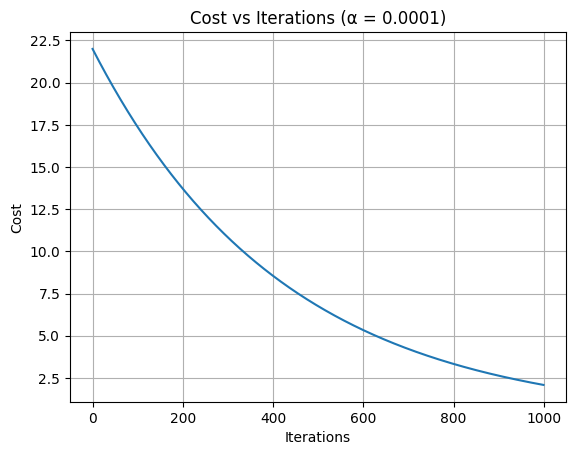

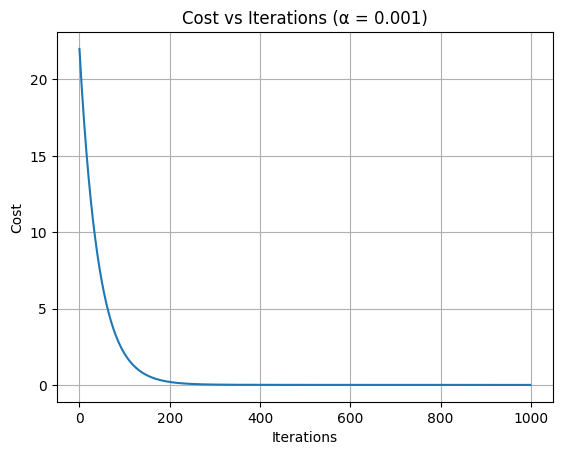

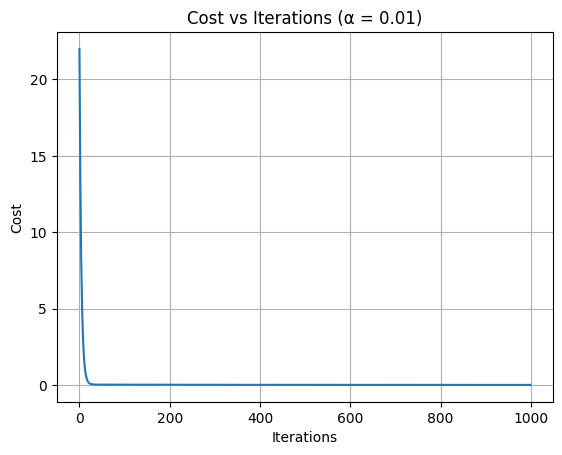

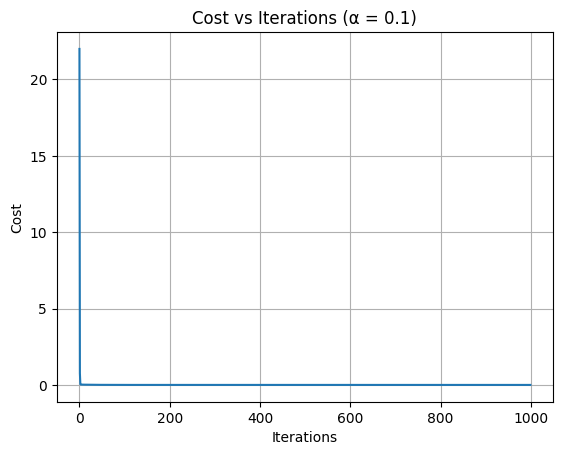

C:\Users\duavi\AppData\Local\Temp\ipykernel_12528\2747506647.py:11: RuntimeWarning: overflow encountered in square
  cost = (1/(2*m)) * np.sum((y_pred - y)**2)


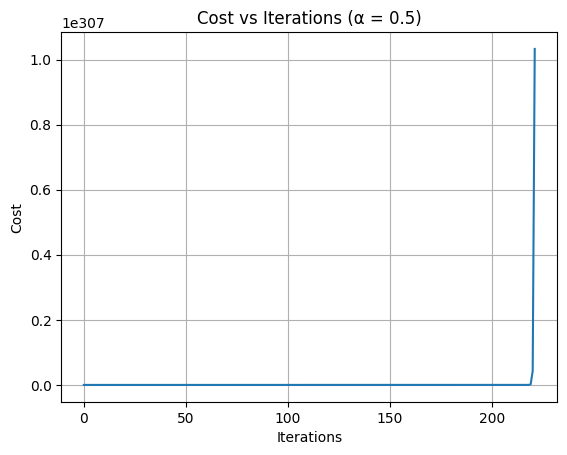

In [20]:
# Cell 5: Plot cost vs iterations for each alpha

for alpha in learning_rates:
    w, b, cost_history = gradient_descent(X, y, alpha, iterations)
    
    plt.figure()
    plt.plot(cost_history)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(f"Cost vs Iterations (α = {alpha})")
    plt.grid()
    plt.show()

In [21]:
# Cell 6: Identification

print("Fastest Convergence: alpha = 0.1")
print("Diverging Learning Rate: alpha = 0.5")

Fastest Convergence: alpha = 0.1
Diverging Learning Rate: alpha = 0.5


### Results and Observations

- **α = 0.0001:**  
  The cost decreases very slowly over iterations, indicating **very slow convergence** due to small updates.

- **α = 0.001:**  
  The model converges steadily, but still requires many iterations to reach a low cost.

- **α = 0.01:**  
  The cost decreases efficiently, showing **good convergence speed** with stable behavior.

- **α = 0.1:**  
  The cost drops rapidly within a few iterations, indicating **fastest convergence** among all learning rates.

- **α = 0.5:**  
  The cost increases drastically and may become extremely large or undefined, indicating **divergence** due to overshooting.

### Observation

- Smaller learning rates lead to slow but stable convergence.  
- Moderate learning rates achieve faster and efficient convergence.  
- Very large learning rates cause instability and divergence due to large parameter updates.